In [1]:
import boto3
import pandas as pd
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bucket = "telco-constumer-churn-066401718601-us-east-2-an"
key = "Raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [3]:
s3 = boto3.client("s3")

response = s3.get_object(
    Bucket=bucket,
    Key=key
)
print(response.keys())

dict_keys(['ResponseMetadata', 'AcceptRanges', 'LastModified', 'ContentLength', 'ETag', 'ChecksumCRC64NVME', 'ChecksumType', 'ContentType', 'ServerSideEncryption', 'Metadata', 'Body'])


In [4]:
df = pd.read_csv(
    BytesIO(response["Body"].read())
)

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Filas: 7043
Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


In [7]:
gender=df['gender'].value_counts()

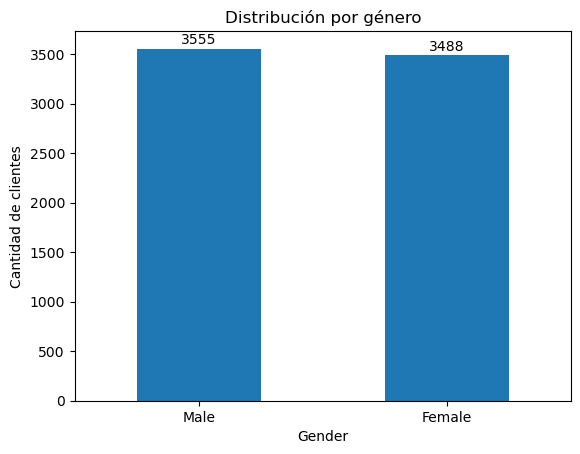

In [8]:
ax = gender.plot(kind="bar")

plt.title("Distribución por género")
plt.xlabel("Gender")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

for i, value in enumerate(gender):
    ax.text(i, value + 50, str(value), ha="center")

plt.show()

In [14]:
gender_total_charges=df.groupby('gender')['TotalCharges'].sum()
gender_total_charges

gender
Female    7952354.2
Male      8103814.5
Name: TotalCharges, dtype: float64

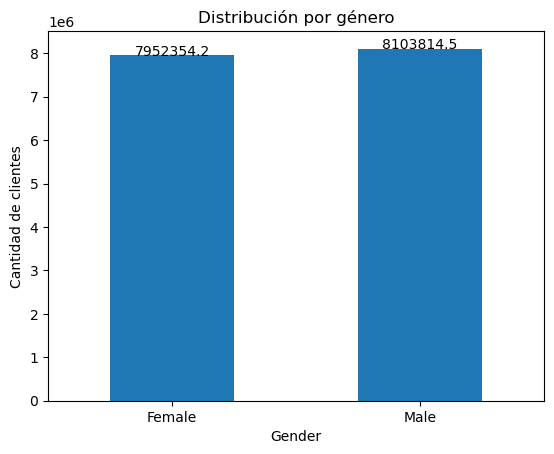

In [15]:
ax = gender_total_charges.plot(kind="bar")

plt.title("Distribución por género")
plt.xlabel("Gender")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

for i, value in enumerate(gender_total_charges):
    ax.text(i, value + 50, str(value), ha="center")

plt.show()

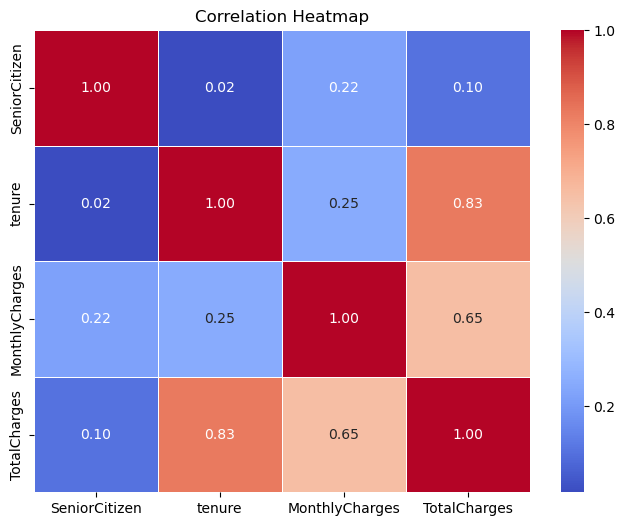

In [17]:
#crear matrix de correlacion
matrix = df._get_numeric_data().corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

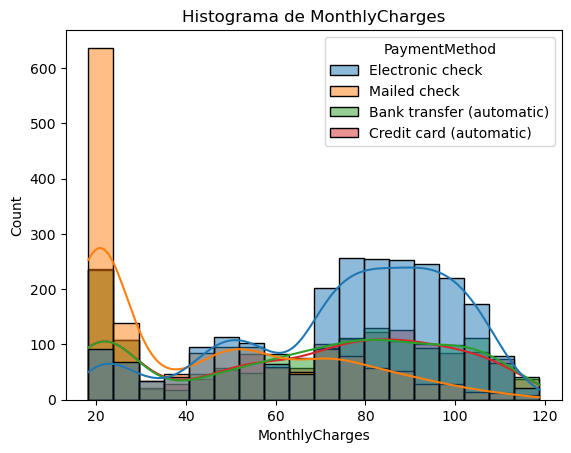

In [20]:
#histograma del pago mensual dependiendo del metodo de pago 
sns.histplot(data=df, x="MonthlyCharges",hue='PaymentMethod',kde=True)
plt.title("Histograma de MonthlyCharges")
plt.show()

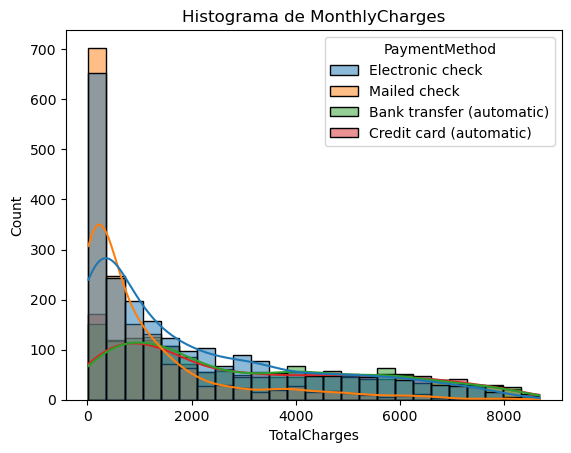

In [21]:
#histograma del pago total dependiendo del metodo de pago 
sns.histplot(data=df, x="TotalCharges",hue='PaymentMethod',kde=True)
plt.title("Histograma de MonthlyCharges")
plt.show()